In [2]:
import pandas as pd
import plotly.express as px
#import plotly.io as pio

#pio.renderers.default = 'iframe'

In [3]:
df = pd.read_csv('coastal_news_clean.csv')

In [4]:
df.head()

,headlines,publication_date,url,location,event_date,category,date
0,Unprotected and open to plunder,2016-05-29,http://www.iol.co.za/news/south-africa/kwazulu...,Eastern Cape,NaN,illegal fishing,2016-05-29 00:00:00.000000000
1,R303m dedicated towards protecting parts of SA...,NaN,http://traveller24.news24.com/Explore/Green/r3...,"Umgeni River Mouth, near the Blue Lagoon estua...",2016-06-08 00:00:00.000000000,waste,2016-06-08 00:00:00.000000000
2,South Africa: Beach Clean-Up to Mark World Oce...,2016-06-13,http://allafrica.com/stories/201606131641.html,"Umgeni River Mouth, near the Blue Lagoon estua...",2016-06-08 00:00:00.000000000,waste,2016-06-08 00:00:00.000000000
3,Spare a thought on World Oceans Day,2016-06-07,http://www.iol.co.za/capetimes/spare-a-thought...,KwaZulu-Natal South Coast and Seaforth Beach i...,2016-06-08 00:00:00.000000000,sea life,2016-06-08 00:00:00.000000000
4,CSIR’s SeaFAR aiding authorities to protect SA...,NaN,http://www.csir.co.za/news/2016/06/Watching%20...,South Africa,2015-05-01 00:00:00.000000000,development,2015-05-01 00:00:00.000000000


In [5]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [6]:
df = df[df['date'] >= '2000-01-01']

In [7]:
# Group by date and category, count articles
timeline_data = df.groupby([df['date'].dt.to_period('M'), 'category']).size().reset_index(name='article_count')

# Convert period back to timestamp for plotting
timeline_data['date'] = timeline_data['date'].dt.to_timestamp()

In [8]:
#print(px.colors.qualitative.Prism)

In [9]:
color_discrete_map={
    'development': 'rgb(15, 133, 84)',
    'illegal fishing': 'rgb(56, 166, 165)',
    'waste':'rgb(102, 102, 102)',
    'red tide': 'rgb(204, 80, 62)',
    'sea life':'rgb(29, 105, 150)',
    'natural event':'rgb(115, 175, 72)'
}

In [10]:
fig = px.bar(timeline_data,
             x='date',
             y='article_count', 
             color='category',
             color_discrete_map=color_discrete_map,    
             labels={'date': 'Date', 'article_count': 'Number of Articles', 'category': 'Category'})

fig.update_layout(barmode='stack',
                 legend=dict(font=dict(
                      family='Arial',
                      size=14,
                      color='black',
                      textcase='word caps'
                  ))
                 )
fig.update_xaxes(categoryorder='category ascending')
fig.show()

In [10]:
category_data = df.groupby(['category']).size().reset_index(name="category_count")

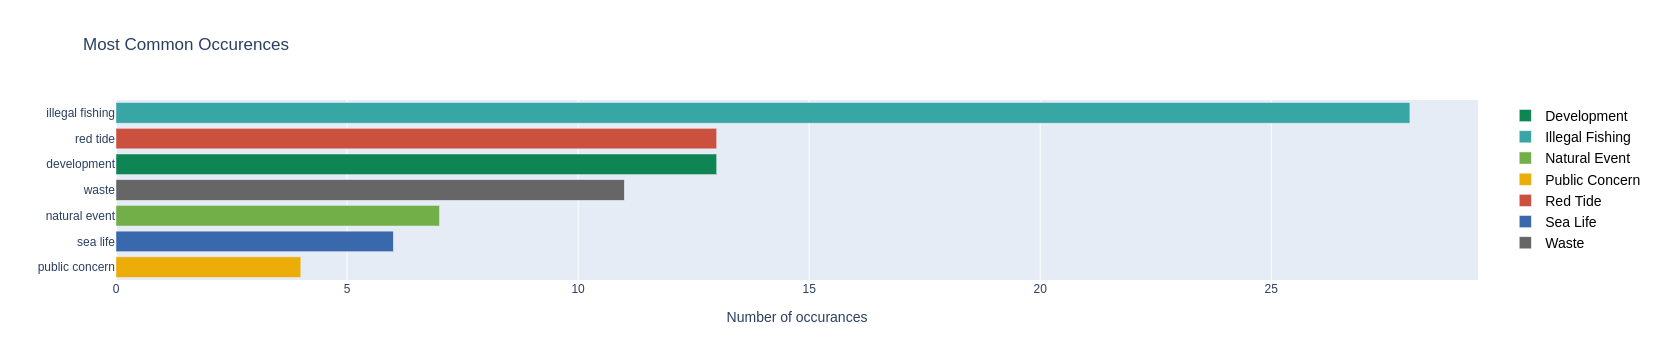

In [ ]:
fig2 = px.bar(category_data,
              x='category_count', 
              y='category',
              orientation='h',
              color='category',
              color_discrete_map=color_discrete_map,
              title='Most Common Occurences',
              labels={'category': '', 'category_count':'Number of occurances'})

fig2.update_layout(yaxis = {"categoryorder":"total ascending"},
                  legend=dict(font=dict(
                      family='Arial',
                      size=14,
                      color='black',
                      textcase='word caps'
                  ))
                  )
fig2.show()

## The Map

In [12]:
df_geo = pd.read_csv('coastal_news_geocoded.csv')

In [13]:
df_geo['date_display'] = pd.to_datetime(df['date']).dt.strftime('%d-%m-%Y')

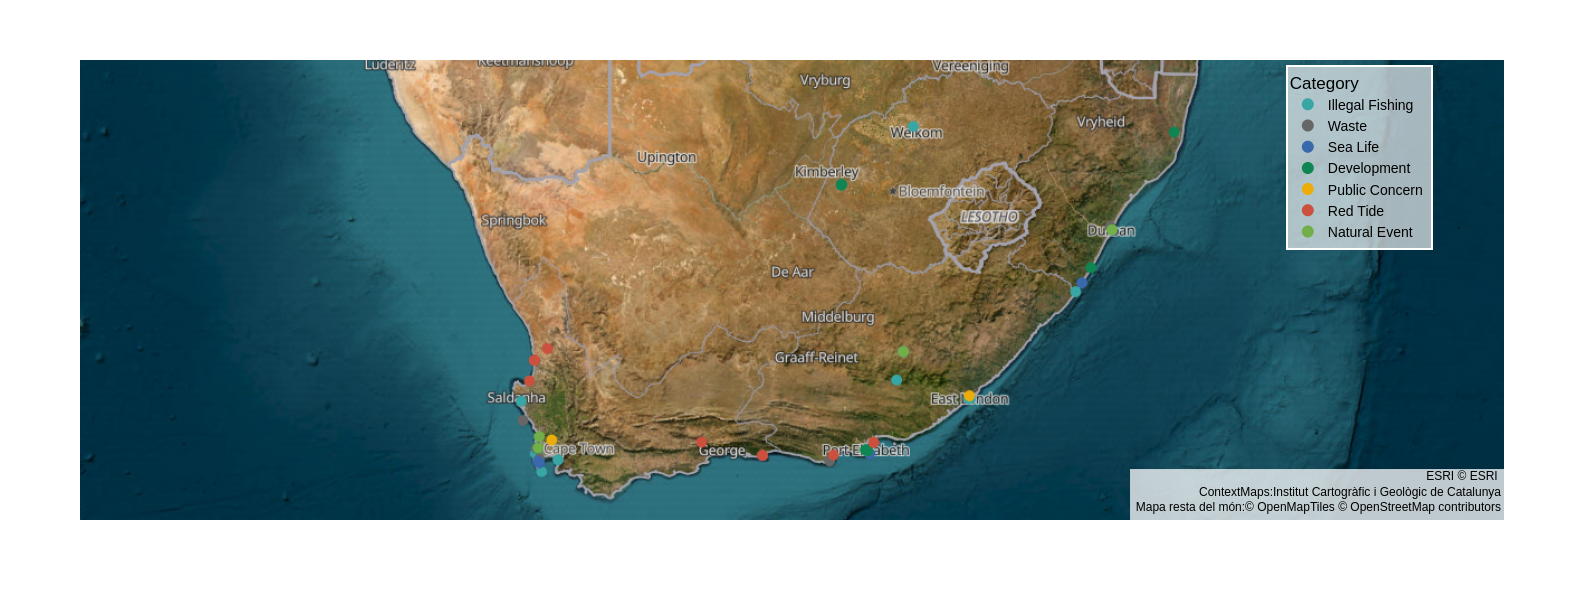

In [59]:
fig4 = px.scatter_map(df_geo,
                      lat="latitude",
                      lon="longitude",
                      color="category",
                      color_discrete_map={
                         'development': 'rgb(15, 133, 84)',
                         'illegal fishing': 'rgb(56, 166, 165)',
                         'waste':'rgb(102, 102, 102)',
                         'red tide': 'rgb(204, 80, 62)',
                         'sea life':'rgb(57, 105, 172)',
                         'natural event':'rgb(115, 175, 72)',
                         'public concern': 'rgb(237, 173, 8)',
                      },
                      hover_name='headlines',
                      hover_data={
                         'headlines': False,
                         'date': False,
                         'date_display': True,
                         'location': True,
                         'latitude': False,
                         'longitude': False
                     })

fig4.update_traces(
    marker=dict(
        size=12
        )
    )

fig4.update_layout(
    autosize=True,
    map=dict(
        center=dict(lat=-31, lon=24),
        zoom=5,
        style='satellite-streets',       
    ),
    legend=dict(
        font=dict(
            family='Arial',
            size=14,
            color='black',
            textcase='word caps'),
        bgcolor='rgba(255, 255, 255, 0.65)',
        bordercolor='white',
        borderwidth=2,
        yanchor="top",
        y=0.99,
        xanchor="right",
        x=0.95),
    height=600
)
fig4.show()